In [322]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [323]:
url='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
df = pd.read_csv(url)

In [324]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [325]:
cols = ['num_cylinders', 'acceleration', 'origin', 'fuel_type', 'drivetrain', 'num_doors']
df = df.drop(cols, axis=1)
print(df)

      engine_displacement  horsepower  vehicle_weight  model_year  \
0                     170       159.0     3413.433759        2003   
1                     130        97.0     3149.664934        2007   
2                     170        78.0     3079.038997        2018   
3                     220         NaN     2542.392402        2009   
4                     210       140.0     3460.870990        2009   
...                   ...         ...             ...         ...   
9699                  140       164.0     2981.107371        2013   
9700                  180       154.0     2439.525729        2004   
9701                  220       138.0     2583.471318        2008   
9702                  230       177.0     2905.527390        2011   
9703                  270       140.0     2908.043477        2005   

      fuel_efficiency_mpg  
0               13.231729  
1               13.688217  
2               14.246341  
3               16.912736  
4               12.488369  
...

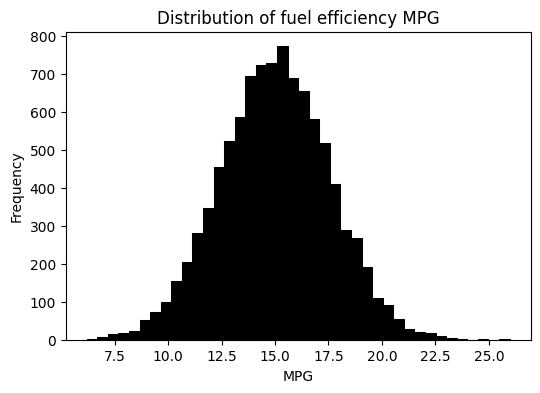

In [326]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 60], bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('MPG')
plt.title('Distribution of fuel efficiency MPG')

plt.show()

In [327]:
# No it does not have a long tail. This is a normal distribution.

In [328]:
# Question 1
missing_columns = df.columns[df.isnull().any()].tolist()
print(missing_columns)
# horsepower is the column with missing values.


['horsepower']


In [329]:
# Question 2
# What's the median (50% percentile) for variable 'horsepower'?
median_value = df['horsepower'].median()
print(median_value)

149.0


In [330]:
# Question 3

In [331]:
# Prepare and spilt the dataset
n = len(df)
# split data into 60%/20%/20% distribution
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
# Use seed 42
np.random.seed(42)
np.random.shuffle(idx)


df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]




In [332]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209


In [333]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [334]:
# add 0 to column horsepower
df.horsepower = df.horsepower.fillna(0)

In [335]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [336]:
y_train = np.log1p(df_train.horsepower.values)
y_val = np.log1p(df_val.horsepower.values)
y_test = np.log1p(df_test.horsepower.values)

In [337]:
del df_train['horsepower']
del df_val['horsepower']
del df_test['horsepower']

In [338]:
print(y_train)

[4.97673374 4.95582706 5.04985601 ... 5.03043792 5.04342512 5.03043792]


In [339]:
df_train.iloc[10]

engine_displacement     240.000000
vehicle_weight         2916.987921
model_year             2001.000000
fuel_efficiency_mpg      15.066416
Name: 10, dtype: float64

In [340]:

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [341]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [342]:
df_train.dtypes

engine_displacement      int64
vehicle_weight         float64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [343]:

base = ['engine_displacement', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']


In [344]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [345]:

y_train = np.where(np.isnan(y_train), 0, y_train)
X_train = df_train[base].fillna(0)
X_train = prepare_X(df_train[base])
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)
score = rmse(y_train, y_pred)
round(score, 2)

np.float64(1.32)

In [346]:
w0, w

(np.float64(-1.0118264094638096),
 array([-2.45271808e-04,  8.98984148e-04,  1.08347879e-04,  1.84934162e-01]))

In [347]:
y_val = np.where(np.isnan(y_val), 0, y_val)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
print(y_val)
score = rmse(y_val, y_pred)
round(score, 2)

[4.72738782 4.93447393 5.20400669 ... 5.31320598 5.13579844 4.77068462]


np.float64(1.29)

In [348]:
# Question 3
# Training data RMSE score is 1.32
# Validation data RMSE score is 1.29
# Validation data RMSE score is lower than training data RMSE score a better result.

In [349]:
# Question 4
# Train a regularized linear regression

In [350]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [351]:
# List of regularization values to test
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

# fill the NAs with 0
X_val = prepare_X(df_val)

for r in r_values:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    round(score, 2)
    print(f"r={r:} RMSE={score:.2f}")

r=0 RMSE=1.29
r=0.01 RMSE=1.29
r=0.1 RMSE=1.29
r=1 RMSE=1.29
r=5 RMSE=1.29
r=10 RMSE=1.29
r=100 RMSE=1.29


In [352]:
# Question 4
# r = 0.01 is the smallest value

In [353]:
# Question 5

In [354]:
from sklearn.linear_model import LinearRegression
# Prepare and spilt the dataset
n = len(df)
# split data into 60%/20%/20% distribution
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)

# List of regularization values to test
seed_values = list(range(10))
# initialize scores list
scores = []
idx = np.arange(n)

# Use seed value from the list
for seed in seed_values:      
  np.random.seed(seed)
  np.random.shuffle(idx) 
  df_train = df.iloc[idx[:n_train]]
  df_val = df.iloc[idx[n_train:n_train+n_val]]
  df_test = df.iloc[idx[n_train+n_val:]]
  # add 0 to column horsepower
  df.horsepower = df.horsepower.fillna(0)

  df_train = df_train.reset_index(drop=True)
  df_val = df_val.reset_index(drop=True)
  df_test = df_test.reset_index(drop=True)

  y_train = np.log1p(df_train.horsepower.values)
  y_val = np.log1p(df_val.horsepower.values)
  y_test = np.log1p(df_test.horsepower.values)

  del df_train['horsepower']
  del df_val['horsepower']
  del df_test['horsepower']

  y_train = np.where(np.isnan(y_train), 0, y_train)
  X_train = prepare_X(df_train)
  # Train without regularization
  model = LinearRegression()
  model.fit(X_train, y_train)

  # Evaluation
  X_val = prepare_X(df_val)
  y_pred = model.predict(X_val)

  score = rmse(y_val, y_pred)
  round(score, 2)
  scores += [score]

# Compute standard deviation of all the scores
stddev = np.std(scores)
print("Standard Deviation:", round(stddev, 3))
# 0.06

Standard Deviation: 0.042


In [355]:
# Question 6
# Split the dataset like previously, use seed 9.
# Combine train and validation datasets.
# Fill the missing values with 0 and train a model with r=0.001.
# What's the RMSE on the test dataset?

In [356]:
# Prepare and spilt the dataset
n = len(df)
# split data into 60%/20%/20% distribution
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
seed = 9

np.random.seed(seed)
np.random.shuffle(idx)


df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]


df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])
y_full_train = np.where(np.isnan(y_full_train), 0, y_full_train)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score


np.float64(1.3041153424173253)

In [357]:
# 0.515